In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

In [2]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeCustom' in i:
            new_name = i.replace('timeCustom_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

def n_to_xr_idx(n):
    """Convert from 1-indexed mesh ID to 0-indexed Python index"""
    return n-1

def xr_to_n_idx(xr):
    """Convert from 0-indexed Python index to 1-indexed mesh ID"""
    return xr+1

def remove_nans(xr_raw):
    xr = np.delete(np.unique(xr_raw), np.unique(xr_raw)==-1)
    return xr

# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'],
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [3]:
sim_res = '5km'
filepath = f'/pscratch/sd/k/kuyeda/WMT_DVD/bichan/{sim_res}/'
# filepath = f'/pub/kailau/WMT_DVD/bichan/{sim_res}/'

suffix = '_30days' # '_with_vertAdv' # '_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' #'_12day_HF_no_adv_no_ALE' #_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' # '_12day_HF_no_adv' # '_12day_HF' '_with_vertAdv '_no_adv'
# averaged values (time = 10*n + 5)
avg_ds_output = xr.open_dataset(filepath + f'/analysis_members/mpaso.hist.am.timeSeriesStatsCustomAvg_{sim_res}_channel.0001-01-01.nc' + suffix,decode_times=False)

# rename variables to remove the "timeCustom_avg" and "activeTracer__" prefixes
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# snapshots at every timestep (dt = 10 mins)
ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
ss_ds_output['salinity'] = ss_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')

mesh = xr.open_dataset(filepath + f'{sim_res}_channel_init.nc')
mesh = mesh.assign_coords({'xr_idx': n_to_xr_idx(mesh.indexToCellID)})
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

time_idx = 500

(300000.0, 325553.3830393002)

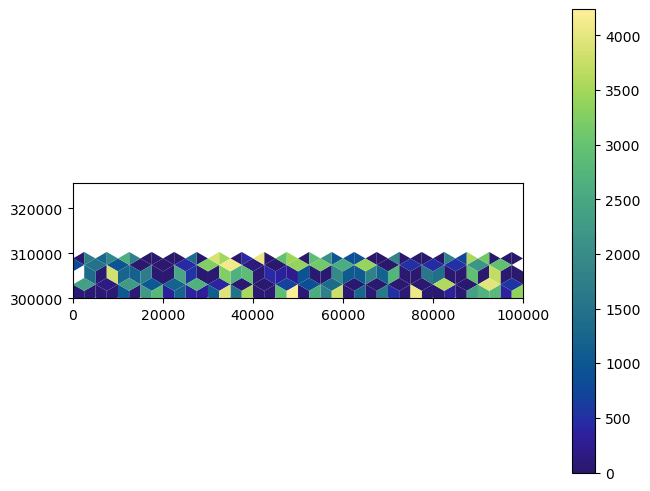

In [4]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nEdges, cmap='cmo.haline')
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)
ax.set_ylim(300000,None)

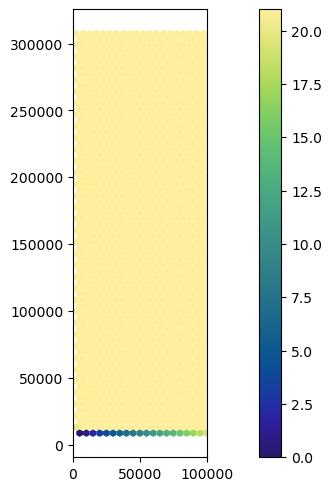

In [5]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nCells, cmap='cmo.haline', vmin=0, vmax = 21)
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)

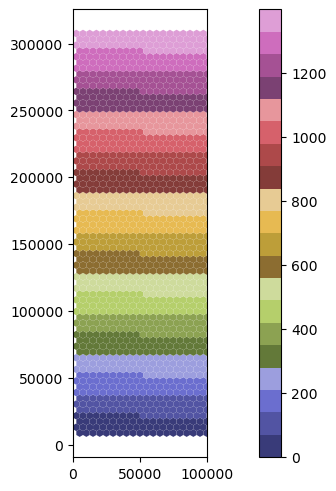

In [6]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nCells, cmap='tab20b')
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)

In [7]:
# set up the same grid as when you calculate G_chi_num
# eventually, this should probably be written as a helper function to be consistent across all budget calculation functions
# set target coordinate bins
ds_output = avg_ds_output
target_coord_spacing = 1

lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array

# create a grid to transform chi from nVertLevels to salinity coords
grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
            padding = 'extend',
            autoparse_metadata = False)


In [8]:
# area-weight all cells to create a new datavariable
avg_ds_output['chiSpurSaltBR08_dA'] = avg_ds_output.chiSpurSaltBR08 * mesh.areaCell

# remap avg_ds_output into salinity space
# transform
chiSpurSaltBR08_dA_salinity = grid.transform(avg_ds_output['chiSpurSaltBR08_dA'], # currently sitting on cell centers
                                 'Z',
                                 target_coords_P1, # conservative remap requires specifying target edge coords
                                 method = 'conservative', # conservative remap since we've already weighted chi with area
                                 target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords

chiSpurSaltBR08_dA_salinity = chiSpurSaltBR08_dA_salinity.to_dataset(name = 'chiSpurSaltBR08_dA_salinity').rename({'salinity_P1' : 'salinity'})
    
# add back salinity_P1 coords
# chiSpurSaltBR08_dA_salinity['salinity_P1'] = target_coords_P1
chiSpurSaltBR08_dA_salinity['chiSpurSaltBR08_dA_salinity'] = chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity.transpose('nCells','Time','salinity')

In [9]:
# create groups of center cell and adjacent cells
# 1. get variable containing xr_idx for all cells in every group
n_groups = xr.concat([mesh.cellsOnCell , xr_to_n_idx(mesh.nCells)], dim = 'maxEdges')
n_groups = n_groups.rename({'maxEdges' : 'xr_cellsInGroup'})
xr_groups_raw = n_to_xr_idx(n_groups)

# select the groups 
grouped_chi_num_dA_raw = chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity.isel(nCells=xr_groups_raw)

# format the groups to remove values that should be NaNs 
# (in _raw, these values are -1, which would adds the last nCell index to the group instead of being blank)
grouped_chi_num_da = grouped_chi_num_dA_raw.where(xr_groups_raw >=0)

# 2. average over the groups
# the dimension 'maxEdges' is actually the cells in that group
# calculate the sum of the area-weighted chi
group_sum_chi_num_dA = grouped_chi_num_da.sum(dim='xr_cellsInGroup', skipna=True, min_count= 1)

# calculate the total area of the group
dA_raw = mesh.areaCell.isel(nCells = xr_groups_raw)
dA = dA_raw.where(xr_groups_raw >= 0)

A = dA.sum(dim='xr_cellsInGroup', skipna=True, min_count=1)

# calculate the average
avg_chi_raw = group_sum_chi_num_dA / A

# 3. mask out center cell values that were previously NaNs before averaging
avg_chi = avg_chi_raw.where(chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity.notnull())



Text(0.5, 0.98, 'Smoothed vs HR $\\chi^{\\text{(num)}}$\nsalinity = 46.96 g/kg')

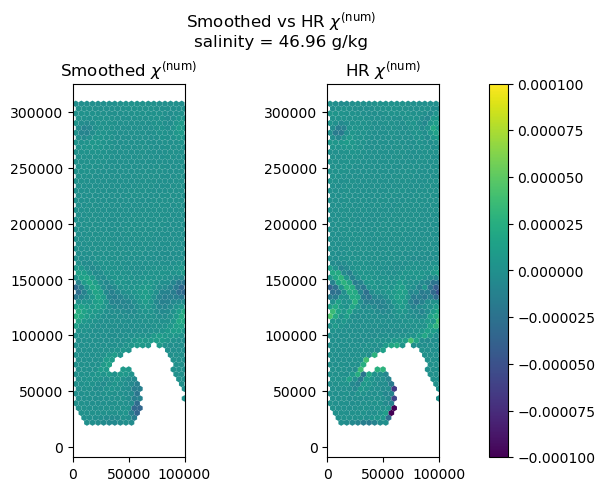

In [53]:
# compare the smoothed vs unsmoothed plots
# on salinity surfaces
chi_num_salinity = grid.transform((avg_ds_output.chiSpurSaltBR08),
                                   'Z',
                                   target_coords_P1,
                                   method = 'conservative',
                                   target_data = avg_ds_output.salinity_P1)
HR_chi = chi_num_salinity.to_dataset(name = 'chi_num_salinity').rename({'salinity_P1' : 'salinity'})

# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =2, constrained_layout=True)
salinity_idx = 35
vmax_val = 1e-4
vmin_val = -vmax_val

a = mosaic.polypcolor(ax[0], descriptor, avg_chi.isel(Time=-1,salinity= salinity_idx),vmin= vmin_val, vmax = vmax_val)
b = mosaic.polypcolor(ax[1], descriptor, HR_chi.chi_num_salinity.isel(Time=-1, salinity = salinity_idx),vmin= vmin_val, vmax = vmax_val)
ax[0].set_aspect(1.0)
ax[1].set_aspect(1.0)

ax[0].set_title(r'Smoothed $\chi^{\text{(num)}}$')
ax[1].set_title(r'HR $\chi^{\text{(num)}}$')

fig.colorbar(a, ax=ax)
fig.suptitle(r'Smoothed vs HR $\chi^{\text{(num)}}$' + '\n' + f'salinity = {np.round(avg_chi.salinity[salinity_idx].values, 2)} g/kg')

In [54]:
# calculate G_mix usng the smoothed values
# since the chi_num term has already been remapped to salinity coordinates, we calculate G_num from a different place than the usual function
# this is already weighted by cell area, so integrating over volume just requires multiplying by the target_lambda_spacing
rho_0 = 1026
chi_dA_num_salinity = avg_chi # HR_chi.chi_num_salinity #avg_chi
chi_dA_num_salinity = chi_dA_num_salinity.to_dataset(name = 'chi_dA_num_salinity').assign_coords({'salinity_P1' : target_coords_P1})

# create a grid for salinity coordinates
salinity_grid = Grid(chi_dA_num_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                     padding = 'extend',
                     autoparse_metadata = False)

target_coord_spacing = 0.5

layerThickness_salinity = grid.transform(avg_ds_output.layerThickness, 
                                      'Z', 
                                      target_coords_P1,
                                      method = 'conservative',
                                      target_data = avg_ds_output.salinity_P1)

layerThickness_salinity = layerThickness_salinity.rename({'salinity_P1' : 'salinity'})

# since the data is already in salinity coords, it would make most sense to calculate the dlambda instead to get dV?
dV_salinity = mesh.areaCell * layerThickness_salinity # target_coord_spacing # layerThickness_salinity

mixing = rho_0 * chi_dA_num_salinity * dV_salinity

# integrate mixing by doing a reverse cumsum over lambda values
cumulative_mixing = salinity_grid.cumsum(mixing.chi_dA_num_salinity,
                                         'Z',
                                         to = 'outer',
                                         reverse='True').to_dataset(name = 'cumulative_chi_num_mixing')

# add back salinity_P1 coords
cumulative_mixing['salinity'] = target_coords

# interpolate back onto salinity coords
cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing.cumulative_chi_num_mixing,
                                                  'Z',
                                                  padding = 'extend').transpose('salinity', 'nCells', 'Time')

# calculate the first derivative (mixing per salinity class) 
# taking a difference will put values back onto salinity_P1 coords
mixingPerSalinityClass = []

# take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
# requires coords to be ordered as (salinity, nCells, Time)

for i in range(0,len(target_coords)-1):
    d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
    d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
    mixingPerSalinityClass.append(d_mixing_d_lambda)

# convert mixingPerSalinityClass to dataarray
mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')

# take the second derivative (from salinity_P1 coords back to salinity coords)
# again, by taking the differrence, you will lose the first and last entries of the salinity coords
# this derivative calculates the convergence of the mixing flux

G_chi_mix = []

for i in range(0,len(target_coords)-2):
    d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
    conv_mixingFlux = d_mixingFlux / d_lambda
    G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2

# convert G_chi_mix to dataset
G_chi_mix_ds_coarsened = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_num')

# add back the salinity_P1 coordinates
G_chi_mix_ds_coarsened = G_chi_mix_ds_coarsened.assign_coords({'salinity_P1' : salinity_P1_trimmed})

In [55]:
G_chi_mix_ds = calculate_G_chi_mix('chiSpurSaltBR08', rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_chi_num


Text(0.5, 0.98, 'Time-averaged WMT budget for $\\mathcal{G}_\\chi^{\\text{(num)}}$\n5km, $\\Delta \\lambda=1$')

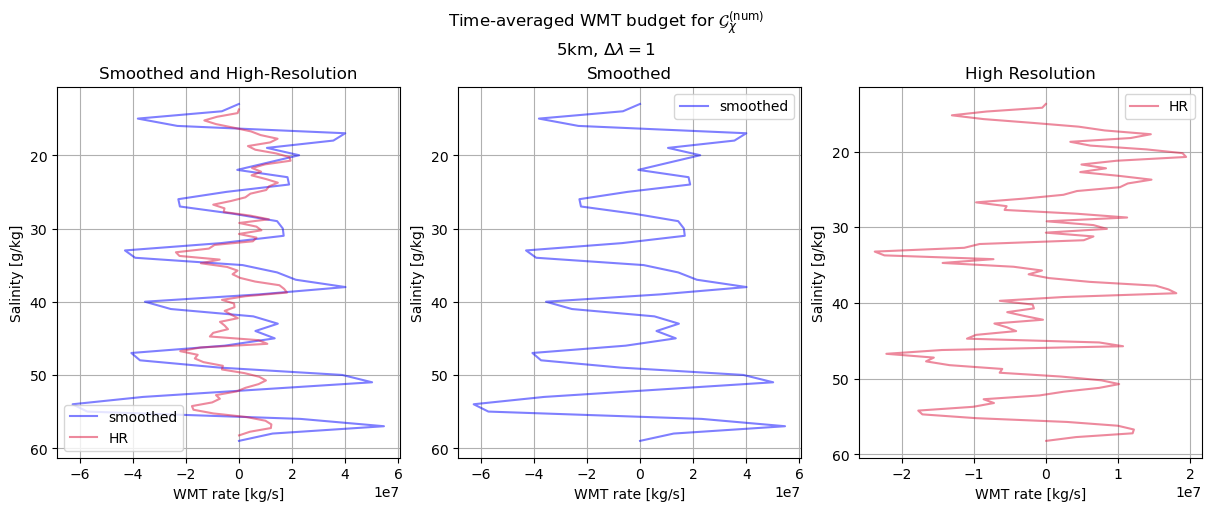

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=3, constrained_layout=True, figsize=(12,5))
G_chi_mix_ds_coarsened.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[0], y='salinity', color='blue', alpha = 0.5, label = 'smoothed')
G_chi_mix_ds.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[0], y='salinity', color = 'crimson', alpha=0.5, label = 'HR')

G_chi_mix_ds_coarsened.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[1], y='salinity', color='blue', alpha = 0.5, label = 'smoothed')
G_chi_mix_ds.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[2], y='salinity', color = 'crimson', alpha=0.5,  label = 'HR')

for i in range(0,3):
    ax[i].grid()
    ax[i].legend()
    ax[i].invert_yaxis()
    ax[i].set_xlabel('WMT rate [kg/s]')
    ax[i].set_ylabel('Salinity [g/kg]')
    
ax[0].set_title('Smoothed and High-Resolution')
ax[1].set_title('Smoothed')
ax[2].set_title('High Resolution')
fig.suptitle(r'Time-averaged WMT budget for $\mathcal{G}_\chi^{\text{(num)}}$' + '\n' + r'5km, $\Delta \lambda=1$')



In [57]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # F_variable = 'salinityVertMixTendency'
    # target_coord_spacing = 1
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
                                                                          'Z',
                                                                          padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy, 'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds

In [58]:
# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'],
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [59]:
def calculate_dt(avg_ds_output):

    time_format = '%Y-%m-%d_%H:%M:%S'
    t0 = datetime.strptime(avg_ds_output.xtime[0].item().decode(), time_format)
    t1 = datetime.strptime(avg_ds_output.xtime[1].item().decode(), time_format)
    
    dt = (t1 - t0).total_seconds()
    return dt

In [60]:
def calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
    # target_coord_spacing = 1
    lower_bound = avg_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = avg_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    
    mass = rho_0 * ss_ds_output.layerThickness * mesh.areaCell
    
    ss_ds_grid = Grid(ss_ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                      padding = 'extend',
                      autoparse_metadata = False)
    
    mass_transform = ss_ds_grid.transform(mass, 
                                'Z',
                                target_coords_P1,
                                method = 'conservative',
                                target_data = ss_ds_output.salinity_P1).fillna(0)
    
    mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})
    
    mass_transform_ds = mass_transform.to_dataset(name='mass_transform')
    mass_transform_ds['salinity_P1'] = target_coords_P1
    mass_transform_ds = mass_transform_ds.set_coords({'salinity_P1' : target_coords_P1})
    
    salinity_grid = Grid(mass_transform_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    mass_vint_salinity_P1 = salinity_grid.cumsum(mass_transform_ds.mass_transform, 
                                                 'Z',
                                                 to = 'outer',
                                                 reverse = True)
    mass_vint_salinity = salinity_grid.interp(mass_vint_salinity_P1, 
                                              'Z',
                                              padding = 'extend').transpose('Time','nCells','salinity')
    
    dM = mass_vint_salinity.diff('Time') 
    dt = calculate_dt(ss_ds_output)
    
    dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')
    
    return mass, mass_transform, dM_dt

In [61]:
def calculate_G_F_num(dM_dt, G_F_phy_ds):
    G_F_num = (dM_dt.dM_dt - G_F_phy_ds.G_F_phy_center).transpose('salinity','nCells','Time')
    G_F_num_ds = G_F_num.to_dataset(name = 'G_F_num')
    return G_F_num_ds

In [62]:
# wrapper function to perform all calculations
def calculate_budget(rho_0, mesh, ds_output, target_coord_spacing = 1):
    print('Calculating G_F_phy')
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

    print('Calculating dM/dt')
    mass, mass_transform, dM_dt_ds = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
    
    print('Calculating G_F_num')
    G_F_num_ds = calculate_G_F_num(dM_dt_ds, G_F_phy_ds)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    budget_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              dM_dt_ds,
                              G_F_num_ds,
                              avg_ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds

In [63]:
# volume integrate G_mix terms, which should = 0
def lambda_integrate_G_mix(variable, target_coord_spacing):
    
    integrated = (budget_ds[variable] * target_coord_spacing).sum(dim=['nCells','salinity']).mean(dim='Time').values
    
    print('lambda_integrated ' + variable + '= %.2E' % integrated )
    return integrated

In [ ]:
rho_0 = 1026
target_coord_spacing = 0.5 # 1 # 0.25

mass, mass_transform, dM_dt = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_F_phy


In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)

# G_phy
budget_ds.G_chi_phy.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$', 
                                                            linestyle='dashed', color='crimson')
budget_ds.G_F_phy_center.sum('nCells').mean(dim='Time').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', color = 'crimson')

# G_num
G_chi_mix_ds_coarsened.G_chi_num.sum('nCells').mean(dim='Time').plot(y='salinity', color='green', 
                                                                     label = r'$\mathcal{G}_\chi^{\text{(num)}}$ smoothed')

budget_ds.G_chi_num.sum('nCells').mean(dim='Time').plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$', 
                                                            linestyle='dashed',color='cornflowerblue')
budget_ds.G_F_num.sum('nCells').mean(dim='Time').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$',
                                                      linewidth = 2, color='cornflowerblue')
# ds_dt.mean(dim='Time').sum('nCells').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

# dM/dt
budget_ds.dM_dt.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\partial_t \mathcal{M}_{\geq}$', color='purple',linewidth = 3)

ax.grid()
# ax.set_ylim(10,60)
# ax.set_xlim(-7e7, 7e7)
ax.legend()
ax.invert_yaxis()
ax.set_xlabel('WMT rate [kg/s]')
ax.set_ylabel('Salinity [g/kg]')
ax.set_title(r'Time-averaged WMT budget for $\mathcal{M}_{\geq}$')

# dM/dt does not go to 0 at salinity = minimum. please just be numerical floating point error or something...